# Optimización Multi-Activo con Sleeve Cripto
## Notebook 01 — Backtest walk-forward OOS del baseline Minimum Variance

*Capítulo 1 — Construcción del baseline y evidencia out-of-sample (gross of costs).*

---

### Resumen

Este notebook documenta y analiza el **baseline** del proyecto: una cartera *Minimum Variance* (MV) con restricciones realistas, evaluada bajo un protocolo *walk-forward* out-of-sample sobre un universo multi-activo —renta variable, renta fija, oro y un sleeve cripto acotado (BTC, ETH)— en el periodo octubre 2018 – mayo 2026. La estrategia se compara con tres benchmarks económicamente significativos: equiponderación, 60/40 (SPY/TLT) y un fixed-small-crypto. Las restricciones operativas son *long-only*, peso máximo por activo del 35% y cap agregado del 20% para crypto, con rebalanceo mensual.

La aportación de este notebook es **descriptiva y metodológica, no inferencial**: (i) hace explícito el protocolo temporal que descarta look-ahead, (ii) reporta rendimiento, drawdown y diagnósticos rolling, (iii) caracteriza la dinámica de asignación —concentración, actividad de los caps y uso real del sleeve cripto— y (iv) examina la implementabilidad mediante *turnover* calculado contra pesos pre-trade *drifted*. Toda la evaluación es **bruta de costes**; el análisis net-of-costs y la robustez paramétrica se reservan al Notebook 02.

### Pregunta de investigación de este capítulo

> Bajo una especificación MV con restricciones y un protocolo walk-forward OOS estricto, ¿qué perfil riesgo–retorno realiza el baseline frente a benchmarks duros, y qué papel descriptivo cumple realmente el sleeve cripto dentro de la asignación?

### Lo que este notebook afirma y lo que no afirma

| Afirma (en esta muestra OOS, gross of costs) | No afirma |
|---|---|
| Un baseline reproducible con protocolo temporal auditable. | Superioridad estadística estructural de MV frente a benchmarks. |
| Evidencia descriptiva sobre reducción de riesgo y control de drawdowns. | Estabilidad de esas propiedades ante perturbaciones paramétricas. |
| Caracterización de pesos, concentración y actividad de caps. | Interpretación causal del mecanismo de entrada de crypto en MV. |
| Una primera lectura de carga operativa vía *turnover*. | Viabilidad económica neta de costes de transacción. |

### Posición en el roadmap

El baseline establecido aquí es **prerrequisito** del Capítulo 2 (Notebook 02), que examina robustez —sensibilidad a lookback, cap cripto, frecuencia de rebalanceo, sample vs. Ledoit-Wolf, gross vs. net— y añade una capa confirmatoria ligera basada en intervalos de bootstrap por bloques sobre diferencias de Sharpe preregistradas. Las extensiones posteriores (regímenes, objetivos de cola, overlays ML) quedan explícitamente fuera de alcance.

> El motor de optimización y backtest reside en `src/backtest.py`, `src/optimizer.py`, `src/costs.py` y se orquesta desde `scripts/run_backtest.py`. Este notebook **no re-ejecuta** el motor: carga artefactos precomputados desde `data/processed/` y los analiza.


## Methodological Audit Update (v0.4.1)

This notebook now follows the corrected baseline:
- Calendar policy: business-day aligned (no weekend rows in baseline returns).
- Holding-period returns: drifted buy-and-hold between monthly rebalances.
- Annualization: 252 observations/year under the baseline.

What changed after audit:
- Calendar alignment avoids mixed 24/7 crypto vs weekday TradFi zero-return artifacts.
- Backtest engine now models intraperiod weight drift and turnover against drifted pre-trade weights.

Interpretation note:
- Crypto exposure should be read as tactical/intermittent, not structural.

### Anclajes de literatura

El diseño se sostiene en cuatro hechos estilizados ampliamente documentados en la literatura de portfolio construction:

- **MV es frágil en *inputs*, no en concepto.** Markowitz (1952) formaliza la minimización de varianza, pero Best & Grauer (1991) y Chopra & Ziemba (1993) muestran que pequeñas perturbaciones en retornos esperados generan movimientos extremos en pesos. De ahí la preferencia por objetivos *risk-only* (Minimum Variance) y por restricciones explícitas como mecanismo regularizador (Jagannathan & Ma, 2003).
- **La diversificación naïve es un benchmark exigente.** DeMiguel, Garlappi & Uppal (2009) documentan que 1/N es difícil de batir OOS una vez se contabiliza honestamente el error de estimación y el turnover. Por eso aquí 1/N es benchmark principal, no espantajo.
- **El error de estimación domina el rendimiento OOS** de la MV no restringida. Ledoit & Wolf (2003, 2004) proponen estimadores con shrinkage como remedio parcial; este es el motivo de la comparación sample vs. Ledoit-Wolf que se realiza en el Capítulo 2 (no en este notebook).
- **Crypto en construcción de carteras.** Liu & Tsyvinski (2021) y Liu, Tsyvinski & Wu (2022) documentan que los retornos cripto se explican débilmente por factores tradicionales y muestran correlaciones variables con renta variable. Esto justifica tratar crypto como un *sleeve acotado* mediante caps explícitos, en vez de como un factor de riesgo estructural.

Estas referencias enmarcan la metodología sin pre-comprometer resultados: justifican por qué MV con restricciones, benchmarks duros y evaluación OOS son un punto de partida razonable antes de añadir shrinkage, objetivos de cola o condicionamiento por régimen.


---
## 1 — Metodología y alcance

### 1.1 Especificación de la estrategia

| Componente | Definición del baseline |
|---|---|
| Objetivo | Minimizar la varianza de cartera: $\min_{w}\; w^{\top}\Sigma w$ |
| Estimador de covarianzas | Covarianza muestral anualizada a partir de retornos simples diarios |
| Ventana de estimación (*lookback*) | 252 días hábiles (~1 año) |
| Rebalanceo | Mensual, primer día hábil |
| Restricciones | Long-only ($w_i \ge 0$); $\sum_i w_i = 1$; $w_i \le 0{,}35$; $w_{\text{BTC}} + w_{\text{ETH}} \le 0{,}20$ |
| Universo | BTC-USD, ETH-USD, SPY, QQQ, GLD, TLT |
| Benchmarks | Equiponderado (1/N), 60/40 (60% SPY / 40% TLT), Fixed Small Crypto |
| Tipo libre de riesgo | $r_f = 0$ (Sharpe sin descontar tasa, consistente entre estrategias) |

Las **restricciones** son ya un mecanismo regularizador: Jagannathan & Ma (2003) muestran que la prohibición de cortos y los caps actúan como un shrinkage implícito, en línea con la conocida fragilidad de la MV no restringida (Best & Grauer, 1991). La covarianza muestral se elige aquí como estimador *más expuesto* al ruido, de modo que cualquier ganancia de robustez observada en el Capítulo 2 (Ledoit-Wolf) sea atribuible limpiamente a la regularización del estimador.

### 1.2 Protocolo walk-forward OOS

Para cada fecha de rebalanceo $t$:

1. Estimar $\hat{\Sigma}_t$ utilizando exclusivamente $[t-\text{lookback},\; t-1]$.
2. Resolver el QP con restricciones para obtener los pesos objetivo $w_t^{\star}$.
3. Mantener $w_t^{\star}$ desde $t$ hasta el siguiente rebalanceo; los pesos pre-trade se *drift* con los retornos realizados.
4. En el rebalanceo $t+1$, calcular el *turnover* one-way contra los pesos **pre-trade drifted**, no contra $w_t^{\star}$ previos:
   $$\text{TO}_{t+1} = \tfrac{1}{2}\sum_i \bigl|\,w_{i,t+1}^{\star}\!-\! w_{i,t+1}^{\text{pre}}\,\bigr|.$$

El protocolo garantiza:

- Ausencia de look-ahead, tanto en la estimación de covarianzas como en la construcción de pesos.
- Un *turnover* alineado con los trades que un gestor ejecutaría realmente.
- Separación temporal estricta entre muestra de estimación y muestra de evaluación: condición *mínima* de credibilidad OOS (DeMiguel, Garlappi & Uppal, 2009).

### 1.3 Qué responde este notebook (y qué no responde)

| Pregunta (descriptiva, OOS, gross) | ¿Se responde aquí? |
|---|---|
| ¿Qué perfil riesgo–retorno produce el baseline frente a los benchmarks? | **Sí** (§3–§4) |
| ¿Cómo evoluciona la asignación y cuán concentrada está? | **Sí** (§5) |
| ¿Qué papel realiza el sleeve cripto dentro de MV? | **Sí, de forma descriptiva** (§5.1) |
| ¿Es plausible la carga operativa bruta? | **Sí** (§6) |
| ¿Son estas propiedades estadísticamente robustas? | **No** — véase Notebook 02 |
| ¿Son robustas a lookback / cap / frecuencia / método de covarianza? | **No** — véase Notebook 02 |
| ¿Son robustas a costes de transacción? | **No** — véase Notebook 02 |


### 1.4 Qué resuelve el protocolo walk-forward OOS — y qué no resuelve

Un protocolo walk-forward OOS es *necesario pero no suficiente* para una evaluación empírica creíble. Conviene explicitar los dos lados.

**Lo que sí resuelve:**
- Separación temporal estricta entre estimación y evaluación.
- Eliminación de look-ahead mecánico tanto en la covarianza como en la construcción de pesos.
- Una evaluación más honesta que cualquier ajuste in-sample, conocido por *favorecer* artificialmente la MV (Michaud, 1989: *"the Markowitz optimisation enigma"*).

**Lo que no resuelve por sí solo:**
- *Error de estimación* en la matriz de covarianzas cuando el tamaño muestral es comparable al cross-section (Ledoit & Wolf, 2003).
- *Dependencia de régimen*: la realización OOS sigue siendo una única extracción de un proceso no estacionario; las correlaciones se rompen justo cuando la diversificación es más necesaria (Longin & Solnik, 2001; Ang & Bekaert, 2002).
- *Inferencia* sobre superioridad de estrategias — requiere intervalos basados en remuestreo, p. ej. circular block bootstrap (Politis & Romano, 1994), introducidos en el Capítulo 2.
- *Viabilidad económica* tras fricciones: los resultados gross sobreestiman el desempeño neto, con un sesgo que escala con el turnover (DeMiguel, Garlappi, Nogales & Uppal, 2009).

La regla de lectura del notebook se deriva de lo anterior: el baseline produce *evidencia dentro de una muestra OOS*, no una afirmación cerrada de superioridad estructural.


---
## 2 — Carga y validación de datos

El notebook consume cuatro artefactos principales producidos por `scripts/run_backtest.py` (más dos opcionales para diagnósticos extendidos):

| Archivo | Rol |
|---|---|
| `portfolio_returns.csv` | Panel diario de retornos OOS (una columna por estrategia). |
| `backtest_summary.csv` | Métricas anuales por estrategia (retorno, vol, Sharpe, MDD, Calmar). |
| `weights_history.csv` | Pesos objetivo en cada fecha de rebalanceo. |
| `turnover_history.csv` | Turnover *pre-trade drifted* one-way y banderas de rebalanceo. |
| `returns_simple.csv` *(opcional)* | Retornos diarios por activo, usados en §5.1 para el diagnóstico de activación cripto. |
| `returns_log.csv` *(opcional)* | Log-retornos; no estrictamente requeridos aquí. |

La celda de validación verifica presencia de columnas, monotonía del índice y paridad de longitudes entre weights y turnover. Si alguna comprobación falla, el análisis se detiene de forma explícita: ningún resultado posterior es fiable sin estos checks.


In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# ── Display layer: human-readable names + consistent visual language ─────────
# Baseline (Min-Var) is the lead series and gets the strongest visual weight.
# Benchmarks are kept in supporting roles with distinct line styles.
STYLE = {
    "min_variance":       {"lw": 2.4, "ls": "-",  "color": "#1f4e79"},  # baseline blue
    "equal_weight":       {"lw": 1.5, "ls": "--", "color": "#d97706"},
    "sixty_forty":        {"lw": 1.5, "ls": "-.", "color": "#2a9d8f"},
    "fixed_small_crypto": {"lw": 1.5, "ls": ":",  "color": "#7d3c98"},
}
LABELS = {
    "min_variance":       "Minimum Variance (baseline)",
    "equal_weight":       "Equiponderado (1/N)",
    "sixty_forty":        "60/40 (SPY/TLT)",
    "fixed_small_crypto": "Fixed Small Crypto",
}
ASSET_LABELS = {
    "BTC-USD": "BTC",
    "ETH-USD": "ETH",
    "SPY":     "SPY (US equity)",
    "QQQ":     "QQQ (US tech)",
    "GLD":     "GLD (oro)",
    "TLT":     "TLT (UST larga)",
}

print(f"Entorno listo · Python {sys.version_info.major}.{sys.version_info.minor} · raíz del proyecto resuelta")


Entorno listo · Python 3.13 · raíz del proyecto resuelta


In [2]:
def _load(filename: str, **kwargs) -> pd.DataFrame | None:
    """Load a processed CSV; print a compact, path-free status line."""
    path = PROCESSED_DIR / filename
    if not path.exists():
        print(f"  [missing]  {filename}")
        return None
    df = pd.read_csv(path, **kwargs)
    print(f"  [loaded ]  {filename:<28s}  {df.shape[0]:>5d} filas × {df.shape[1]:>2d} cols")
    return df


print("Carga de outputs procesados:\n")

portfolio_returns = _load("portfolio_returns.csv",  index_col=0, parse_dates=True)
backtest_summary  = _load("backtest_summary.csv",   index_col=0)
weights_history   = _load("weights_history.csv",    index_col=0, parse_dates=True)
turnover_history  = _load("turnover_history.csv",   index_col=0, parse_dates=True)

# Optional inputs for richer descriptive diagnostics
returns_simple = _load("returns_simple.csv", index_col=0, parse_dates=True)
returns_log    = _load("returns_log.csv",    index_col=0, parse_dates=True)


Carga de outputs procesados:

  [loaded ]  portfolio_returns.csv          2771 filas ×  4 cols
  [loaded ]  backtest_summary.csv              4 filas ×  5 cols
  [loaded ]  weights_history.csv              92 filas ×  6 cols
  [loaded ]  turnover_history.csv             92 filas ×  4 cols
  [loaded ]  returns_simple.csv             3042 filas ×  6 cols
  [loaded ]  returns_log.csv                3042 filas ×  6 cols


In [3]:
# ── Structural validation ─────────────────────────────────────────────────────
print("\nValidaciones estructurales:")

EXPECTED = {
    "portfolio_returns": ["min_variance", "equal_weight", "sixty_forty", "fixed_small_crypto"],
    "backtest_summary":  ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar"],
    "weights_history":   ["BTC-USD", "ETH-USD", "SPY", "QQQ", "GLD", "TLT"],
    "turnover_history":  ["turnover_one_way", "is_initial_rebalance"],
}

dfs = {
    "portfolio_returns": portfolio_returns,
    "backtest_summary":  backtest_summary,
    "weights_history":   weights_history,
    "turnover_history":  turnover_history,
}

all_ok = True
for name, expected_cols in EXPECTED.items():
    df = dfs[name]
    if df is None:
        print(f"  [missing]  {name}: archivo ausente — celdas posteriores fallarán")
        all_ok = False
        continue
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        print(f"  [warn   ]  {name}: faltan columnas {missing}")
        all_ok = False
    else:
        print(f"  [ok     ]  {name}: columnas esperadas presentes")

# Optional files: informative only
for name, df in {"returns_simple": returns_simple, "returns_log": returns_log}.items():
    if df is None:
        print(f"  [info   ]  {name}: opcional, no disponible")
    else:
        print(f"  [ok     ]  {name}: disponible para diagnósticos extendidos")

# Date range summary
if portfolio_returns is not None:
    idx = portfolio_returns.index
    assert idx.is_monotonic_increasing, "portfolio_returns index not sorted"
    print(f"\nVentana OOS    : {idx[0].date()} → {idx[-1].date()}  ({len(idx)} días hábiles)")

if weights_history is not None and turnover_history is not None:
    assert len(weights_history) == len(turnover_history), \
        f"Length mismatch: weights={len(weights_history)}, turnover={len(turnover_history)}"
    print(f"Rebalanceos    : {len(weights_history)}")

print("\nChecks principales OK." if all_ok else "\nFallos en checks principales — revisar arriba.")



Validaciones estructurales:
  [ok     ]  portfolio_returns: columnas esperadas presentes
  [ok     ]  backtest_summary: columnas esperadas presentes
  [ok     ]  weights_history: columnas esperadas presentes
  [ok     ]  turnover_history: columnas esperadas presentes
  [ok     ]  returns_simple: disponible para diagnósticos extendidos
  [ok     ]  returns_log: disponible para diagnósticos extendidos

Ventana OOS    : 2018-10-01 → 2026-05-02  (2771 días hábiles)
Rebalanceos    : 92

Checks principales OK.


---
## 3 — Performance OOS

Métricas anualizadas por estrategia para la ventana completa OOS (octubre 2018 – mayo 2026), cargadas desde `backtest_summary.csv`. La primera tabla muestra niveles brutos; la segunda muestra el diferencial de cada benchmark frente a Minimum Variance, en puntos porcentuales (pp) para retorno, volatilidad y MDD, y en unidades para Sharpe — para hacer explícito el trade-off.


In [4]:
DISPLAY_COLS = {
    "ann_return":     "Ann. Return",
    "ann_volatility": "Ann. Volatility",
    "sharpe":         "Sharpe Ratio",
    "max_drawdown":   "Max Drawdown",
    "calmar":         "Calmar Ratio",
}
STRATEGY_ORDER = ["min_variance", "equal_weight", "sixty_forty", "fixed_small_crypto"]

summary_tbl = backtest_summary.reindex(STRATEGY_ORDER)[list(DISPLAY_COLS)].copy()
summary_tbl.index = [LABELS.get(s, s) for s in summary_tbl.index]
summary_tbl.columns = list(DISPLAY_COLS.values())

fmt = summary_tbl.copy().astype(object)
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown"]:
    fmt[col] = summary_tbl[col].map(lambda x: f"{x*100:+.2f}%")
for col in ["Sharpe Ratio", "Calmar Ratio"]:
    fmt[col] = summary_tbl[col].map(lambda x: f"{x:.3f}")

fmt

,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
Minimum Variance (baseline),+8.32%,+8.94%,0.930,-23.33%,0.356
Equiponderado (1/N),+18.74%,+22.31%,0.840,-45.33%,0.413
60/40 (SPY/TLT),+6.01%,+10.48%,0.574,-27.24%,0.221
Fixed Small Crypto,+12.47%,+12.52%,0.996,-30.41%,0.410


### Lectura

**Pregunta.** ¿Qué trade-off produce **Minimum Variance** frente a los tres benchmarks en esta muestra OOS?

**Evidencia (niveles y diferenciales).**
- Frente a **Equiponderado**, MV cede ~10,4 pp de retorno anual (8,32% vs. 18,74%), pero recorta ~13,4 pp de volatilidad anual (8,94% vs. 22,31%), lo que equivale a una reducción relativa de ~60%, y mejora el max drawdown en ~22,0 pp (−23,3% vs. −45,3%).
- Frente a **60/40**, MV añade ~2,3 pp de retorno y, al mismo tiempo, recorta ~1,5 pp de volatilidad; el Sharpe aumenta en ~0,36 (0,93 vs. 0,57).
- Frente a **Fixed Small Crypto**, MV pierde ~4,2 pp de retorno y ~0,07 de Sharpe, pero lo hace con una volatilidad ~3,6 pp menor y un drawdown máximo ~6,8 pp menos profundo.

**Interpretación.** El baseline no maximiza retorno; produce, más bien, una forma de *eficiencia defensiva*. Comprime de manera sistemática la dispersión de los rendimientos y la severidad de la cola izquierda. La ventaja de Sharpe frente a 60/40 y la cercanía a **Fixed Small Crypto** sugieren que la cesión de retorno no se traduce necesariamente en un peor perfil ajustado por riesgo, al menos en esta realización.

**Límite inferencial.** Se trata de estimaciones puntuales sobre una única trayectoria OOS, brutas de costes y sin inferencia formal. La advertencia de DeMiguel, Garlappi y Uppal (2009) aplica de forma directa: diferencias de Sharpe de esta magnitud pueden caer dentro de la incertidumbre de bootstrap en muestras moderadas. El Notebook 02 retoma precisamente esa cuestión. Por tanto, esta sección debe leerse como una *cartografía* del trade-off riesgo-retorno, no como un veredicto definitivo.

---
## 4 — Equity y drawdowns

Las curvas de equity se indexan a 100 al inicio del OOS; los drawdowns se calculan como $\text{DD}_t = W_t/\max_{s\le t} W_s - 1$. Se anotan dos marcadores estilizados de régimen — el shock COVID (Q1-2020) y el ciclo de subidas de tipos de 2022 — solo como anclas de lectura, no como argumento causal.


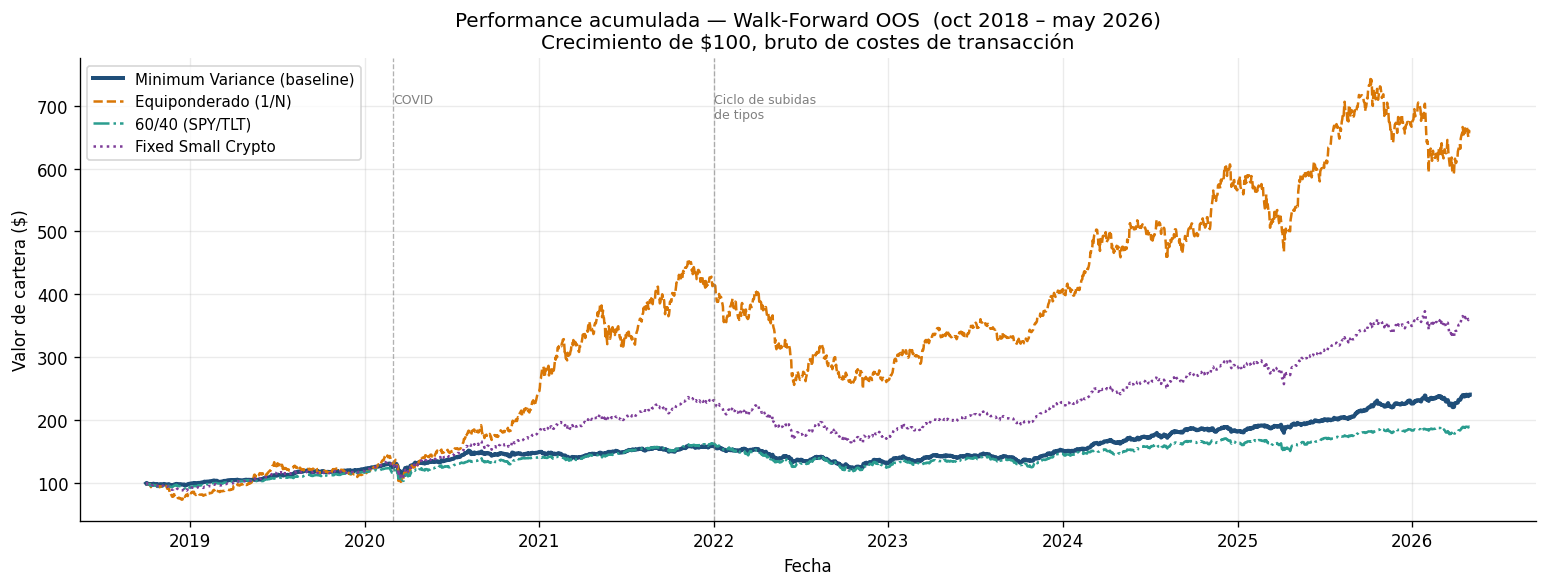

In [5]:
# ── Curvas de equity — indexadas a 100 al inicio del OOS ─────────────────────
cumulative = (1 + portfolio_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(13, 5))

for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(cumulative.index, cumulative[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])

# Anclas de régimen (no causales)
for year, label in [(2020.2, "COVID"), (2022.0, "Ciclo de subidas\nde tipos")]:
    ts = pd.Timestamp(f"{int(year)}-{int((year % 1)*12)+1:02d}-01")
    ax.axvline(ts, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.text(ts, cumulative.max().max() * 0.97, label, fontsize=7.5,
            color="grey", ha="left", va="top")

ax.set_title("Performance acumulada — Walk-Forward OOS  (oct 2018 – may 2026)\n"
             "Crecimiento de $100, bruto de costes de transacción", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor de cartera ($)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()


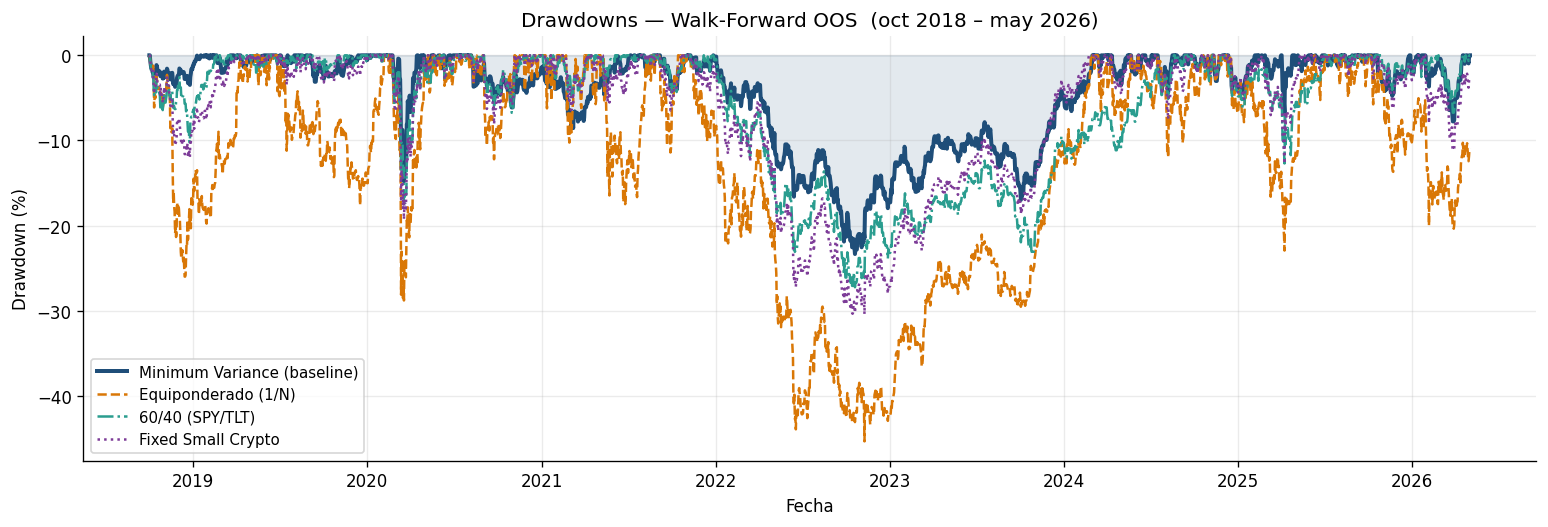

In [6]:
# ── Drawdowns ────────────────────────────────────────────────────────────────
def _drawdown(returns: pd.Series) -> pd.Series:
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1.0) * 100   # en %

drawdowns = portfolio_returns.apply(_drawdown)

fig, ax = plt.subplots(figsize=(13, 4.5))

for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(drawdowns.index, drawdowns[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])

# Sombreado del baseline para enfatizar el envelope defensivo
ax.fill_between(drawdowns.index, drawdowns["min_variance"], 0,
                alpha=0.12, color=STYLE["min_variance"]["color"])

ax.set_title("Drawdowns — Walk-Forward OOS  (oct 2018 – may 2026)", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()


### Lectura

**Dinámica de equity.** La dispersión entre estrategias se concentra de forma desproporcionada en el ciclo alcista cripto de 2020–2021: Equiponderado y Fixed Small Crypto capturan ese régimen mecánicamente; MV y 60/40 no lo hacen. A partir de 2022 los rangos se comprimen: MV recupera desde una pérdida de capital menor, mientras que Equiponderado conserva más convexidad alcista pero parte de una base más erosionada.

**Drawdowns.** El sobre de drawdown de MV es uniformemente el más estrecho. Su peor episodio (~−23%, 2022–2023) coincide con un régimen en el que renta variable y duración se comprimieron simultáneamente — el escenario de libro de texto en el que la diversificación long-only sobre SPY/QQQ/TLT/GLD encuentra su límite estructural. El mínimo de Equiponderado (~−45%) es coherente con el comportamiento de cola izquierda bien documentado de la exposición cripto sin presupuesto explícito (Liu & Tsyvinski, 2021). 60/40 pasa un periodo inusualmente largo bajo el agua en 2022–2023, ilustrando la dependencia de régimen de la correlación stock–bond (Longin & Solnik, 2001; Ang & Bekaert, 2002).

**Límite inferencial.** Las formas de drawdown son *path-dependent y sample-specific*. Permiten caracterizar el comportamiento de cola realizado, pero no identifican por sí mismas un orden estructural — el episodio de correlación stock–bond de 2022 es un evento único en esta muestra.


### 4.1 Diagnósticos rolling

Las métricas headline resumen una trayectoria; las ventanas rolling indican si las propiedades son *episódicas* o *persistentes*. Se usa una ventana de 126 días (~6 meses): suficientemente corta para registrar cambios de régimen y suficientemente larga para amortiguar ruido de alta frecuencia. Volatilidad y retorno se reportan anualizados. El Sharpe rolling se calcula como ratio de los dos: siguiendo la práctica estándar, debe leerse direccionalmente — su distribución muestral es ancha y de colas pesadas (Lo, 2002).


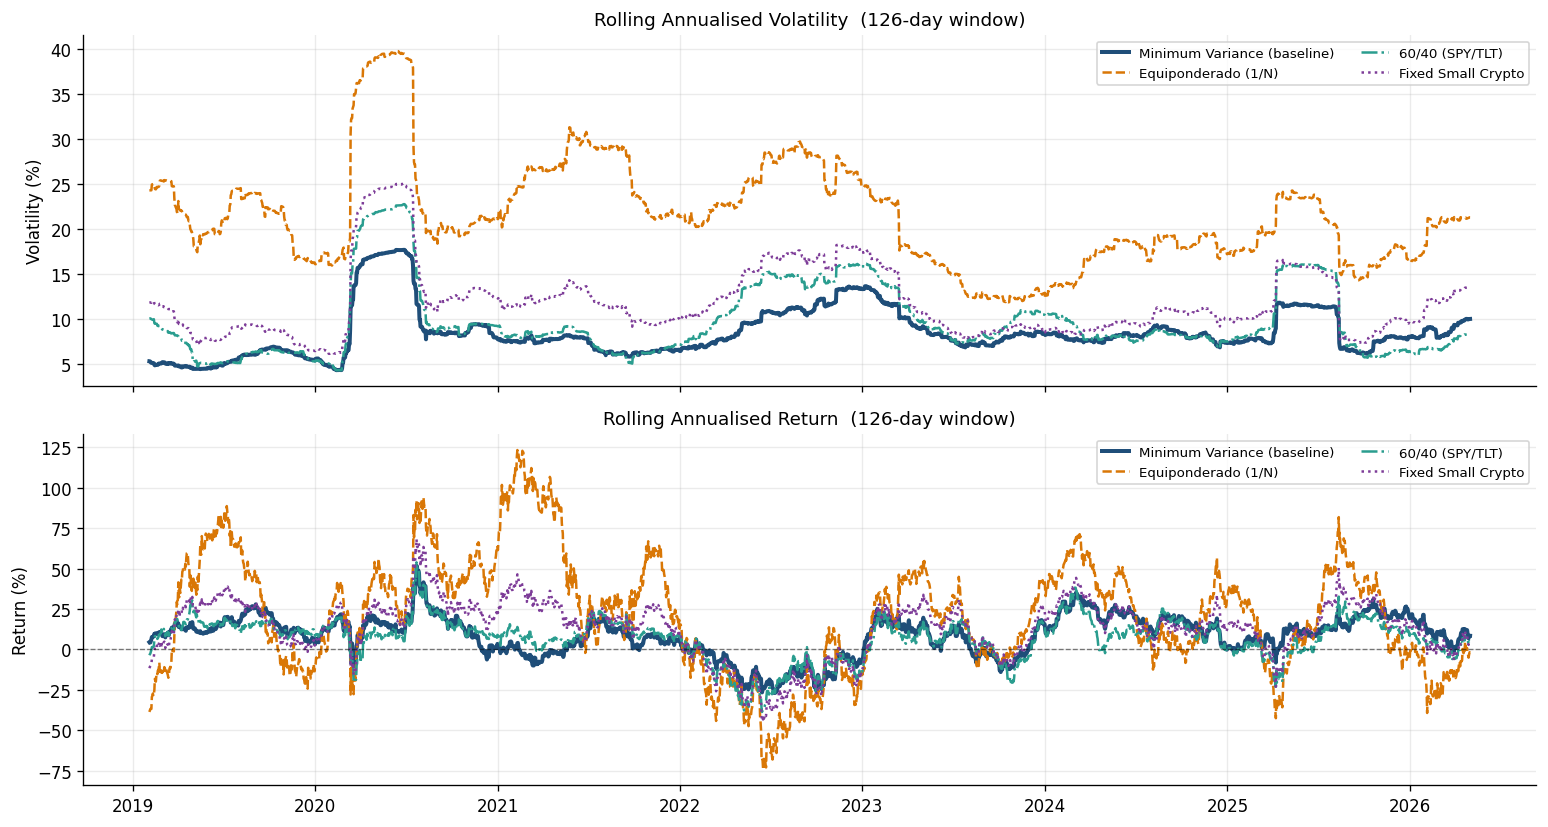

In [7]:
ROLL_WIN = 126  # ~6 months — documented window choice

roll_vol = portfolio_returns.rolling(ROLL_WIN).std() * np.sqrt(252) * 100   # annualised %
roll_ret = portfolio_returns.rolling(ROLL_WIN).mean() * 252 * 100           # annualised %

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── Rolling volatility ────────────────────────────────────────────────────────
ax = axes[0]
for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(roll_vol.index, roll_vol[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])
ax.set_title(f"Rolling Annualised Volatility  ({ROLL_WIN}-day window)", fontsize=11)
ax.set_ylabel("Volatility (%)")
ax.legend(loc="upper right", fontsize=8, ncol=2)

# ── Rolling return ────────────────────────────────────────────────────────────
ax = axes[1]
for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(roll_ret.index, roll_ret[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_title(f"Rolling Annualised Return  ({ROLL_WIN}-day window)", fontsize=11)
ax.set_ylabel("Return (%)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

fig.tight_layout()
plt.show()

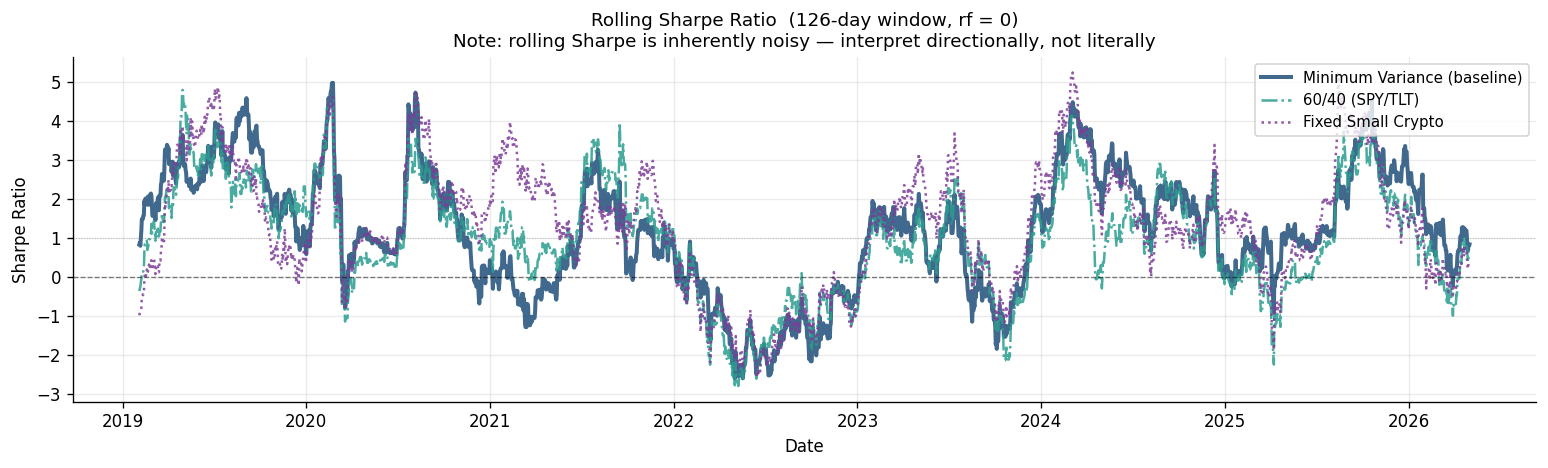

In [8]:
# ── Rolling Sharpe ────────────────────────────────────────────────────────────
# Defined as (rolling annualised return) / (rolling annualised vol).
# Note: with rf = 0 throughout. Shown only for min_variance, sixty_forty, and
# fixed_small_crypto — equal_weight is excluded because its extreme vol swings
# make the Sharpe line erratic and visually dominant without adding clarity.

roll_sharpe = (roll_ret / roll_vol).dropna(how="all")

SHARPE_COLS = ["min_variance", "sixty_forty", "fixed_small_crypto"]

fig, ax = plt.subplots(figsize=(13, 4))

for col in SHARPE_COLS:
    s = STYLE[col]
    ax.plot(roll_sharpe.index, roll_sharpe[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"], alpha=0.85)

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.axhline(1, color="grey",  lw=0.6, ls=":",  alpha=0.5)

ax.set_title(f"Rolling Sharpe Ratio  ({ROLL_WIN}-day window, rf = 0)\n"
             "Note: rolling Sharpe is inherently noisy — interpret directionally, not literally",
             fontsize=11)
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()

In [9]:
# Rolling evidence summary (diagnostic, not inferential)
valid_roll_vol = roll_vol.dropna()
valid_roll_sharpe = roll_sharpe.dropna()

lowest_vol_share = {
    c: (valid_roll_vol.idxmin(axis=1) == c).mean() * 100 for c in valid_roll_vol.columns
}
positive_sharpe_share = {
    c: (valid_roll_sharpe[c] > 0).mean() * 100 for c in SHARPE_COLS
}

rolling_evidence = pd.DataFrame({
    "share_lowest_rolling_vol_%": pd.Series(lowest_vol_share),
    "share_positive_rolling_sharpe_%": pd.Series(positive_sharpe_share),
}).round(2)

rolling_evidence

,share_lowest_rolling_vol_%,share_positive_rolling_sharpe_%
equal_weight,0.00,NaN
fixed_small_crypto,0.00,81.18
min_variance,75.43,77.48
sixty_forty,24.57,76.57


### Lectura de los diagnósticos rolling

**Pregunta.** ¿Las propiedades defensivas son episódicas o persistentes a lo largo de la muestra OOS?

**Evidencia.**
- MV registra la *menor* volatilidad rolling anualizada en ~75% de las ventanas válidas; 60/40 captura la mayor parte del resto (~25%). Equiponderado y Fixed Small Crypto rara vez lideran en volatilidad.
- El Sharpe rolling es positivo en ~77% de las ventanas para MV, ~77% para 60/40 y ~81% para Fixed Small Crypto.

**Interpretación.** El perfil defensivo del baseline es *persistente*, no concentrado en uno o dos episodios. La mayor proporción de Sharpe rolling positivo de Fixed Small Crypto refleja exposición path-dependent al ciclo 2020–2021 y va acompañada de una distribución mucho más ancha y drawdowns más profundos en 2022 (visibles en §4).

**Límite inferencial.** Las frecuencias del tipo "share of windows leading" son frecuencias descriptivas, *no* tests: las ventanas rolling están autocorrelacionadas, la variabilidad muestral del Sharpe es alta (Lo, 2002), y el conteo es condicional a una única estructura de solapamiento. Léanse como diagnósticos coherentes con la imagen de equity, no como evidencia de superioridad estructural.


---
## 5 — Dinámica de la asignación: pesos, concentración y caps

Esta sección abre la caja: cómo despliega el optimizador el capital, cuán concentrada queda la asignación y con qué frecuencia activan las restricciones. La actividad de los caps es informativa por sí misma — Jagannathan & Ma (2003) muestran que los caps vinculantes actúan como un shrinkage implícito y explican una parte no trivial del rendimiento OOS de MV.

**Definiciones.**
- **Activo activo:** peso $> 0{,}5\%$ ($\theta_{\text{active}} = 0{,}005$).
- **Cap hit:** peso a menos de 0,5 pp del cap por activo (35%) o del cap agregado de crypto (20%).
- **Concentración:** índice de Herfindahl $\text{HHI}_t = \sum_i w_{i,t}^2$ y número efectivo de apuestas $\text{ENB}_t = 1/\text{HHI}_t$ (Bouchaud, Potters & Aguilar, 1997).

**Regla de lectura.** Un ENB bajo no implica mecánicamente *concentración de riesgo*: la concentración de riesgo "verdadera" se mide vía contribuciones marginales a la varianza, lo cual requiere el estado de covarianza por rebalanceo y se difiere a fases posteriores. HHI/ENB es, aquí, un diagnóstico en *espacio de pesos*.


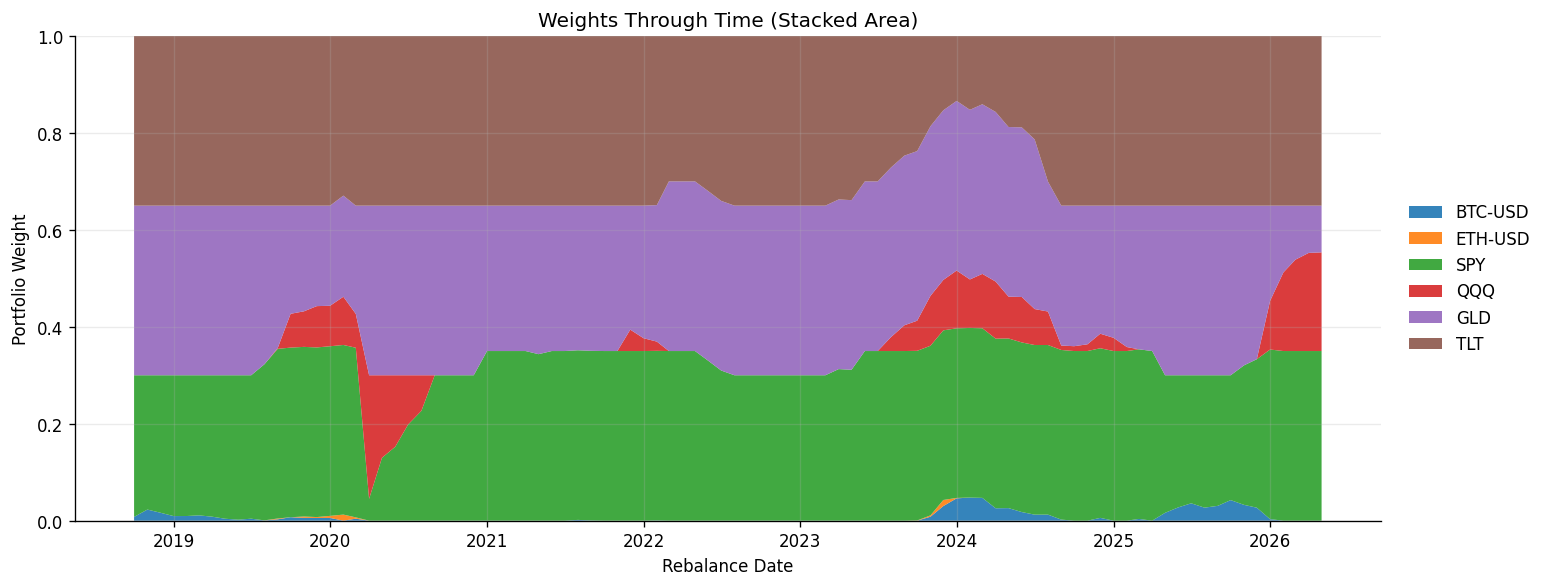

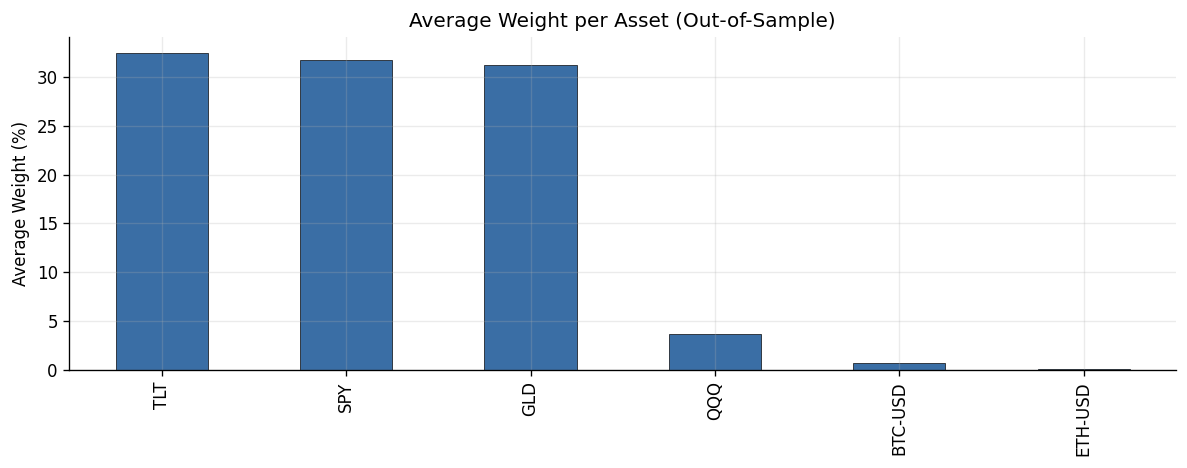

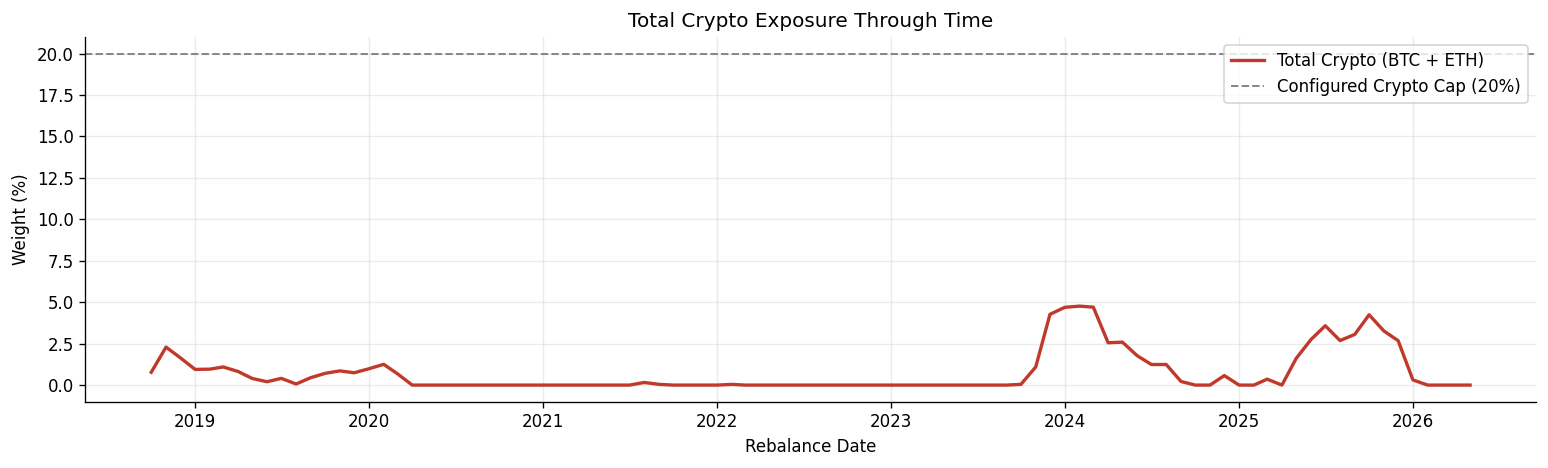

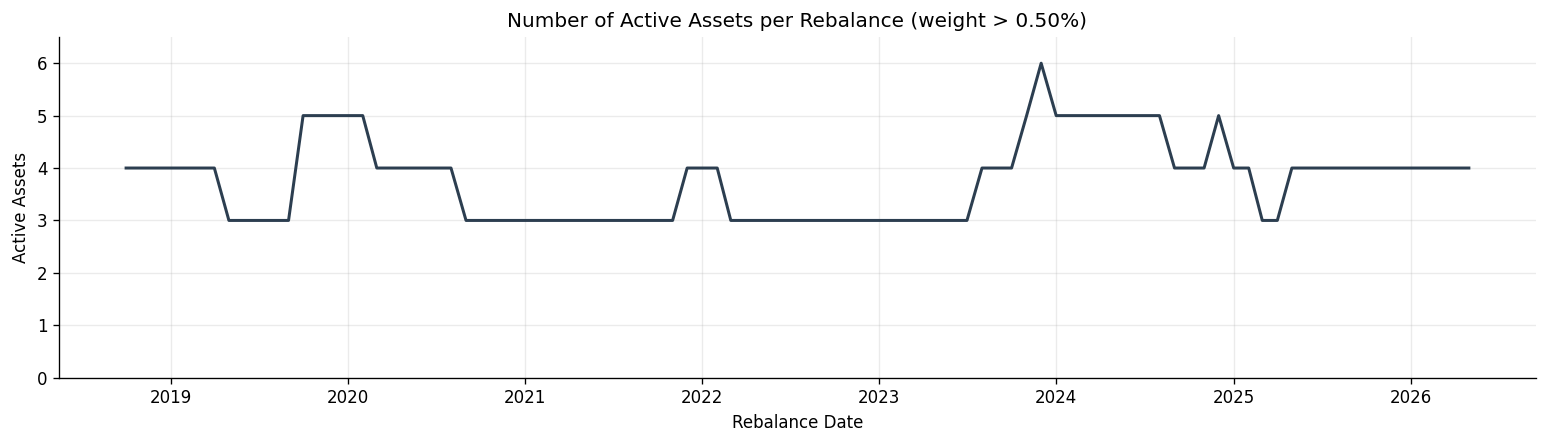

Cap-hit frequency by asset (near/touching max_weight_per_asset):


,cap_hits_count,cap_hits_pct
TLT,69,75.00
GLD,54,58.70
SPY,51,55.43
BTC-USD,0,0.00
ETH-USD,0,0.00
QQQ,0,0.00


Crypto total cap near-hits (BTC+ETH >= 19.5%): 0/92 rebalances (0.00%)


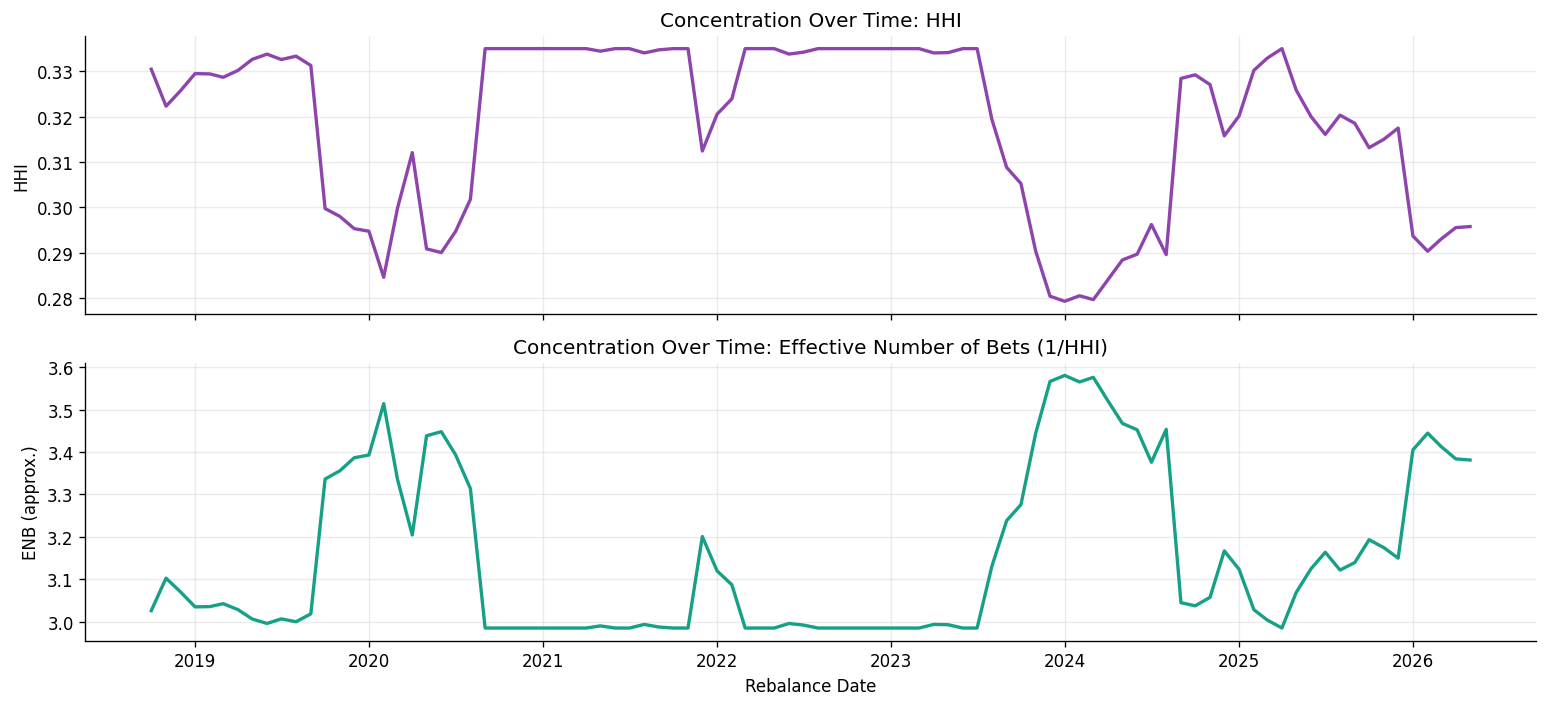

Concentration summary statistics:


,mean,std,min,25%,50%,75%,max
HHI,0.318664,0.018623,0.279258,0.299781,0.328553,0.335000,0.335000
ENB_approx,3.149260,0.193226,2.985075,2.985075,3.043652,3.335763,3.580923


Crypto exposure summary (%):


,value
crypto_mean_%,0.759
crypto_median_%,0.000
crypto_max_%,4.763
share_rebalances_crypto_gt_5%,0.000
share_rebalances_crypto_gt_10%,0.000


Active assets summary:


,value
active_assets_mean,3.761
active_assets_median,4.000
active_assets_min,3.000
active_assets_max,6.000


In [10]:
# ---- Section 5A-F: weights diagnostics --------------------------------------

ASSET_CAP = 0.35
CRYPTO_TOTAL_CAP = 0.20
ACTIVE_THRESHOLD = 0.005   # 0.5%
CAP_EPS = 0.005            # within 0.5pp of the cap is treated as "near cap"

w = weights_history.copy().sort_index()

# Keep plotting order aligned with weight columns
weight_cols = [c for c in STRATEGY_ORDER if c in w.columns]
if len(weight_cols) != len(w.columns):
    weight_cols = list(w.columns)

# A) Time evolution of weights (stacked area)
fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    w.index,
    *[w[c].values for c in weight_cols],
    labels=weight_cols,
    alpha=0.9
)
ax.set_title("Weights Through Time (Stacked Area)", fontsize=12)
ax.set_ylabel("Portfolio Weight")
ax.set_xlabel("Rebalance Date")
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
plt.show()

# B) Average weight per asset
mean_w = w.mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 4))
mean_w.plot(kind="bar", ax=ax, color="#3A6EA5", edgecolor="black", linewidth=0.4)
ax.set_title("Average Weight per Asset (Out-of-Sample)", fontsize=12)
ax.set_ylabel("Average Weight (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

# C) Total crypto exposure over time
crypto_cols = [c for c in ["BTC-USD", "ETH-USD"] if c in w.columns]
crypto_exposure = w[crypto_cols].sum(axis=1) if crypto_cols else pd.Series(index=w.index, dtype=float)

fig, ax = plt.subplots(figsize=(13, 4))
if len(crypto_cols):
    ax.plot(crypto_exposure.index, crypto_exposure.values * 100,
            color="#C0392B", lw=2.0, label="Total Crypto (BTC + ETH)")
    ax.axhline(CRYPTO_TOTAL_CAP * 100, color="#7F8C8D", ls="--", lw=1.2,
               label=f"Configured Crypto Cap ({CRYPTO_TOTAL_CAP:.0%})")
ax.set_title("Total Crypto Exposure Through Time", fontsize=12)
ax.set_ylabel("Weight (%)")
ax.set_xlabel("Rebalance Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
if len(crypto_cols):
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# D) Number of active assets per rebalance
n_active_assets = (w > ACTIVE_THRESHOLD).sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(n_active_assets.index, n_active_assets.values, color="#2C3E50", lw=1.8)
ax.set_title(f"Number of Active Assets per Rebalance (weight > {ACTIVE_THRESHOLD:.2%})", fontsize=12)
ax.set_ylabel("Active Assets")
ax.set_xlabel("Rebalance Date")
ax.set_ylim(0, len(w.columns) + 0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# E) Cap-hit frequency (per asset + crypto total)
asset_cap_hits = (w >= (ASSET_CAP - CAP_EPS)).sum().sort_values(ascending=False)
asset_cap_hits_pct = (asset_cap_hits / len(w) * 100).round(2)

cap_hits_tbl = pd.DataFrame({
    "cap_hits_count": asset_cap_hits,
    "cap_hits_pct": asset_cap_hits_pct,
}).astype({"cap_hits_count": int})

if len(crypto_cols):
    crypto_cap_hits_count = int((crypto_exposure >= (CRYPTO_TOTAL_CAP - CAP_EPS)).sum())
    crypto_cap_hits_pct = round(crypto_cap_hits_count / len(w) * 100, 2)
else:
    crypto_cap_hits_count = 0
    crypto_cap_hits_pct = 0.0

print("Cap-hit frequency by asset (near/touching max_weight_per_asset):")
display(cap_hits_tbl)
if len(crypto_cols):
    print(
        f"Crypto total cap near-hits (BTC+ETH >= {CRYPTO_TOTAL_CAP - CAP_EPS:.1%}): "
        f"{crypto_cap_hits_count}/{len(w)} rebalances ({crypto_cap_hits_pct:.2f}%)"
    )

# F) Concentration: HHI and effective number of bets
hhi = (w ** 2).sum(axis=1)
enb = 1.0 / hhi

concentration = pd.DataFrame({
    "HHI": hhi,
    "ENB_approx": enb,
})

concentration_summary = concentration.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(concentration.index, concentration["HHI"], color="#8E44AD", lw=2)
axes[0].set_title("Concentration Over Time: HHI", fontsize=12)
axes[0].set_ylabel("HHI")
axes[0].grid(alpha=0.25)

axes[1].plot(concentration.index, concentration["ENB_approx"], color="#16A085", lw=2)
axes[1].set_title("Concentration Over Time: Effective Number of Bets (1/HHI)", fontsize=12)
axes[1].set_ylabel("ENB (approx.)")
axes[1].set_xlabel("Rebalance Date")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Quantified summaries for interpretation
if len(crypto_cols):
    crypto_summary = pd.Series({
        "crypto_mean_%": crypto_exposure.mean() * 100,
        "crypto_median_%": crypto_exposure.median() * 100,
        "crypto_max_%": crypto_exposure.max() * 100,
        "share_rebalances_crypto_gt_5%": (crypto_exposure > 0.05).mean() * 100,
        "share_rebalances_crypto_gt_10%": (crypto_exposure > 0.10).mean() * 100,
    }).round(3)
else:
    crypto_summary = pd.Series(dtype=float)

active_assets_summary = pd.Series({
    "active_assets_mean": n_active_assets.mean(),
    "active_assets_median": n_active_assets.median(),
    "active_assets_min": n_active_assets.min(),
    "active_assets_max": n_active_assets.max(),
}).round(3)

print("Concentration summary statistics:")
display(concentration_summary)
print("Crypto exposure summary (%):")
display(crypto_summary.to_frame("value"))
print("Active assets summary:")
display(active_assets_summary.to_frame("value"))

# Expose section-level artifacts for later narrative / Section 6 relationships
weights_section_artifacts = {
    "mean_weights_pct": mean_w,
    "n_active_assets": n_active_assets,
    "cap_hits_table": cap_hits_tbl,
    "crypto_cap_hits_count": crypto_cap_hits_count,
    "crypto_cap_hits_pct": crypto_cap_hits_pct,
    "concentration": concentration,
    "concentration_summary": concentration_summary,
    "crypto_exposure": crypto_exposure,
    "crypto_summary": crypto_summary,
    "active_assets_summary": active_assets_summary,
    "active_threshold": ACTIVE_THRESHOLD,
    "asset_cap": ASSET_CAP,
    "crypto_total_cap": CRYPTO_TOTAL_CAP,
    "cap_eps": CAP_EPS,
}

### Lectura de la dinámica de asignación

**P1 — ¿MV usa realmente crypto?**
- *Evidencia.* Peso cripto medio agregado ≈ 0,76%, mediana 0,0%, máximo ~4,8%. Frecuencia por encima del 5% = 0%; por encima del 10% = 0%.
- *Lectura.* El sleeve cripto está *disponible* (cap = 20%) pero apenas se *utiliza* por la MV con covarianza muestral en esta realización OOS. El cap del 20% no es vinculante en ningún momento.
- *Límite.* "Uso marginal" no es lo mismo que "sin contribución": incluso asignaciones pequeñas pueden mover localmente óptimos derivados de covarianza. Esa es la razón estructural por la que existe el control sin crypto en el Notebook 02.

**P2 — ¿Diversificada o concentrada?**
- *Evidencia.* HHI medio ≈ 0,32; ENB medio ≈ 3,15 sobre un universo de 6 activos; activos activos por rebalanceo: media 3,76, rango 3–6.
- *Lectura.* Diversificación *parcial* con concentración moderada — exactamente la tipología que produce una MV restringida cuando los caps están activos (Jagannathan & Ma, 2003).
- *Límite.* Concentración en pesos $\neq$ concentración en riesgo; lo segundo requeriría contribución marginal a la varianza, fuera del alcance de este notebook.

**P3 — ¿Qué activos dominan, y aparecen soluciones de esquina?**
- *Evidencia.* Pesos medios dominantes en TLT (~32,3%), SPY (~31,6%) y GLD (~31,1%); frecuencia de cap hit: TLT 75,0%, GLD 58,7%, SPY 55,4%.
- *Lectura.* Los activos defensivos / tradicionales estructuran el núcleo; los caps por activo son *económicamente* activos, en línea con la lógica regularizadora de Jagannathan & Ma (2003).
- *Límite.* Un cap vinculante no es un error del modelo: es el óptimo dentro del conjunto factible que el gestor define.

**P4 — ¿Pesos estables o erráticos?**
- *Evidencia.* El stacked-area muestra estabilidad por bloques; el contador de activos activos varía en una banda estrecha.
- *Lectura.* Estructura estable con ajustes discretos en puntos de inflexión de régimen — coherente con MV restringida y lookback de 1 año.
- *Límite.* La estabilidad observacional no es una prueba formal de estabilidad; haría falta bootstrap-based stability sobre los pesos.


### 5.1 ¿Por qué entra crypto en Minimum Variance?

El optimizador no observa retornos directamente: observa la *covarianza reciente*. El sleeve cripto entra en MV cuando la ventana trailing percibe (i) una volatilidad que es alta pero no catastrófica relativa al resto y (ii) correlaciones con activos tradicionales suficientemente bajas como para que crypto participe en la combinación ponderada que minimiza la varianza.

Esta subsección es estrictamente **descriptiva**. Compara las condiciones trailing de retorno / volatilidad / correlación en aquellas fechas en las que crypto recibe una asignación *material* frente a las que no. Explícitamente *no* se estima un modelo estructural: no hay validación cruzada de las condiciones, no hay identificación causal, y la comparación es condicional al camino realizado de precios y restricciones.


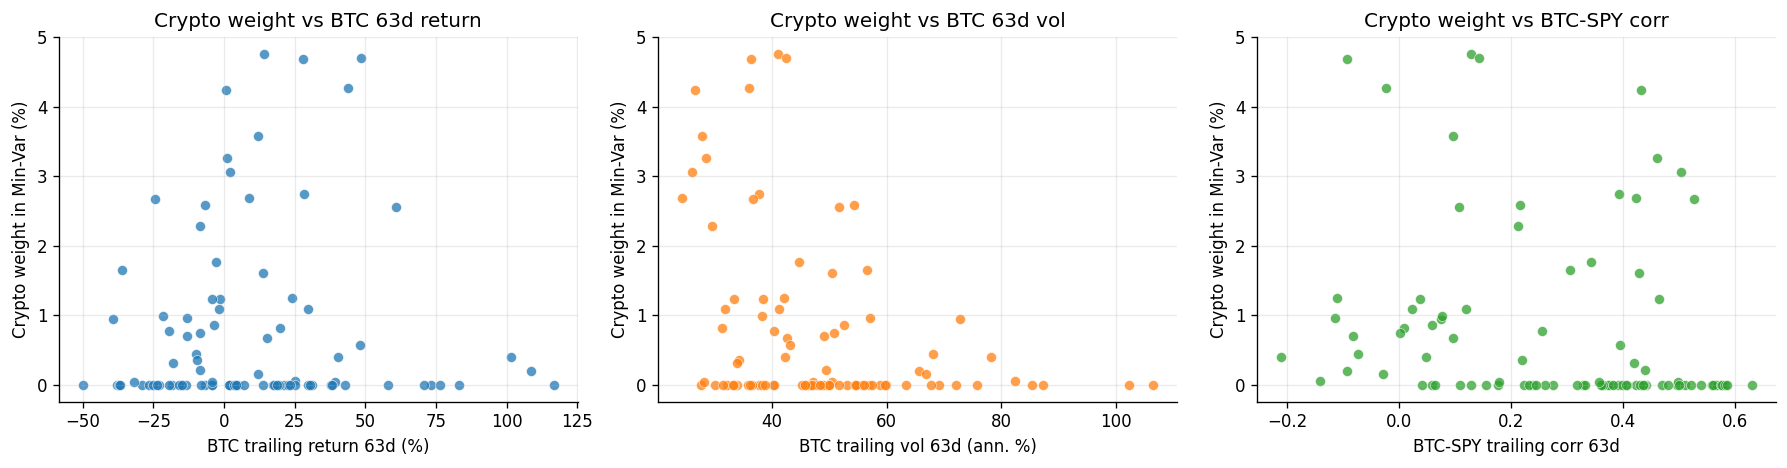

[Info] No observations above 5%; using adaptive material threshold = 2.00%.
Average trailing conditions by crypto-activation regime:


,btc_ret_63,btc_ret_126,btc_vol_63,btc_vol_126,btc_spy_corr_63,btc_tlt_corr_63,eth_ret_63,eth_vol_63
crypto_material,14.899,30.793,35.667,36.201,0.251,-0.037,20.027,57.108
crypto_near_zero,9.963,25.241,51.785,52.543,0.298,0.005,12.150,67.131


Top rebalance dates by crypto allocation (diagnostic):


,crypto_weight,btc_ret_63,btc_vol_63,btc_spy_corr_63
rebalance_date,,,,
2024-02-01,4.763,14.221,41.036,0.129
2024-03-01,4.702,48.317,42.541,0.142
2024-01-01,4.692,28.012,36.332,-0.093
2023-12-01,4.269,43.762,36.096,-0.024
2025-10-01,4.243,0.694,26.556,0.431
2025-07-01,3.582,12.105,27.904,0.096
2025-11-01,3.266,1.154,28.545,0.460
2025-09-01,3.059,1.974,26.045,0.503
2025-06-01,2.747,28.321,37.785,0.391


Activation sample summary:


,value
n_rebalances_used,92.000
material_threshold_used_%,2.000
n_material_crypto,14.000
share_material_crypto,15.217
n_near_zero_crypto_<=1%,70.000


In [11]:
# Descriptive diagnostics of crypto activation at rebalance dates
if returns_simple is None:
    print("returns_simple.csv no disponible: se omite diagnóstico de activación cripto por condiciones trailing.")
    crypto_activation = None
else:
    required_cols = ["BTC-USD", "ETH-USD", "SPY", "TLT"]
    missing_cols = [c for c in required_cols if c not in returns_simple.columns]

    if missing_cols:
        print(f"returns_simple disponible pero faltan columnas {missing_cols}; diagnóstico limitado.")
        crypto_activation = None
    else:
        rs = returns_simple.sort_index().copy()
        rb_idx = weights_history.index

        def trailing_return(series: pd.Series, window: int) -> pd.Series:
            return (1 + series).rolling(window).apply(np.prod, raw=True) - 1

        feat = pd.DataFrame(index=rs.index)
        feat["btc_ret_63"] = trailing_return(rs["BTC-USD"], 63)
        feat["btc_ret_126"] = trailing_return(rs["BTC-USD"], 126)
        feat["btc_vol_63"] = rs["BTC-USD"].rolling(63).std() * np.sqrt(252)
        feat["btc_vol_126"] = rs["BTC-USD"].rolling(126).std() * np.sqrt(252)
        feat["btc_spy_corr_63"] = rs["BTC-USD"].rolling(63).corr(rs["SPY"])
        feat["btc_tlt_corr_63"] = rs["BTC-USD"].rolling(63).corr(rs["TLT"])
        feat["eth_ret_63"] = trailing_return(rs["ETH-USD"], 63)
        feat["eth_vol_63"] = rs["ETH-USD"].rolling(63).std() * np.sqrt(252)

        crypto_total = weights_history[[c for c in ["BTC-USD", "ETH-USD"] if c in weights_history.columns]].sum(axis=1)

        crypto_activation = pd.DataFrame(index=rb_idx)
        crypto_activation["crypto_weight"] = crypto_total
        crypto_activation = crypto_activation.join(feat.reindex(rb_idx), how="left").dropna()

        if crypto_activation.empty:
            print("No hay intersección suficiente entre fechas de rebalance y features trailing.")
        else:
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))

            axes[0].scatter(crypto_activation["btc_ret_63"] * 100,
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#1F77B4", edgecolor="white", linewidth=0.4)
            axes[0].set_xlabel("BTC trailing return 63d (%)")
            axes[0].set_ylabel("Crypto weight in Min-Var (%)")
            axes[0].set_title("Crypto weight vs BTC 63d return")
            axes[0].grid(alpha=0.25)

            axes[1].scatter(crypto_activation["btc_vol_63"] * 100,
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#FF7F0E", edgecolor="white", linewidth=0.4)
            axes[1].set_xlabel("BTC trailing vol 63d (ann. %)")
            axes[1].set_ylabel("Crypto weight in Min-Var (%)")
            axes[1].set_title("Crypto weight vs BTC 63d vol")
            axes[1].grid(alpha=0.25)

            axes[2].scatter(crypto_activation["btc_spy_corr_63"],
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#2CA02C", edgecolor="white", linewidth=0.4)
            axes[2].set_xlabel("BTC-SPY trailing corr 63d")
            axes[2].set_ylabel("Crypto weight in Min-Var (%)")
            axes[2].set_title("Crypto weight vs BTC-SPY corr")
            axes[2].grid(alpha=0.25)

            fig.tight_layout()
            plt.show()

            # Material threshold: fixed first (5%), then adaptive fallback if empty
            material_threshold = 0.05
            low_threshold = 0.01
            material = crypto_activation[crypto_activation["crypto_weight"] > material_threshold]
            if material.empty:
                material_threshold = max(0.02, crypto_activation["crypto_weight"].quantile(0.75))
                material = crypto_activation[crypto_activation["crypto_weight"] > material_threshold]
                print(f"[Info] No observations above 5%; using adaptive material threshold = {material_threshold:.2%}.")

            near_zero = crypto_activation[crypto_activation["crypto_weight"] <= low_threshold]

            compare_cols = [
                "btc_ret_63", "btc_ret_126", "btc_vol_63", "btc_vol_126",
                "btc_spy_corr_63", "btc_tlt_corr_63", "eth_ret_63", "eth_vol_63"
            ]

            comparison = pd.DataFrame(index=["crypto_material", "crypto_near_zero"], columns=compare_cols, dtype=float)
            if not material.empty:
                comparison.loc["crypto_material"] = material[compare_cols].mean().values
            if not near_zero.empty:
                comparison.loc["crypto_near_zero"] = near_zero[compare_cols].mean().values

            comparison_display = comparison.copy()
            for c in ["btc_ret_63", "btc_ret_126", "eth_ret_63"]:
                comparison_display[c] = comparison_display[c] * 100
            for c in ["btc_vol_63", "btc_vol_126", "eth_vol_63"]:
                comparison_display[c] = comparison_display[c] * 100
            comparison_display = comparison_display.round(3)

            print("Average trailing conditions by crypto-activation regime:")
            display(comparison_display)

            top_crypto_dates = material[["crypto_weight", "btc_ret_63", "btc_vol_63", "btc_spy_corr_63"]].copy()
            top_crypto_dates = top_crypto_dates.sort_values("crypto_weight", ascending=False).head(12)
            top_crypto_dates[["crypto_weight", "btc_ret_63", "btc_vol_63"]] *= 100
            top_crypto_dates = top_crypto_dates.round(3)

            print("Top rebalance dates by crypto allocation (diagnostic):")
            display(top_crypto_dates)

            activation_summary = pd.Series({
                "n_rebalances_used": len(crypto_activation),
                "material_threshold_used_%": material_threshold * 100,
                "n_material_crypto": int((crypto_activation["crypto_weight"] > material_threshold).sum()),
                "share_material_crypto": (crypto_activation["crypto_weight"] > material_threshold).mean() * 100,
                "n_near_zero_crypto_<=1%": int((crypto_activation["crypto_weight"] <= low_threshold).sum()),
            }).round(3)
            print("Activation sample summary:")
            display(activation_summary.to_frame("value"))

### Lectura del diagnóstico de activación

**Pregunta.** ¿La entrada de crypto coincide con condiciones trailing potencialmente favorables?

**Evidencia.**
- Ningún rebalanceo presenta crypto > 5%; usamos un umbral adaptativo de materialidad ≈ 2% para separar regímenes.
- Bajo ese umbral: ~14/92 rebalanceos (~15%) son *materiales*, ~70/92 son *near-zero* (≤ 1%).
- En media, los periodos materiales muestran mayor retorno trailing de BTC (63d y 126d) y menor volatilidad trailing de BTC/ETH que los periodos near-zero.
- Las correlaciones trailing BTC–SPY y BTC–TLT muestran señal *mixta*: no hay un patrón limpio de "desacople", la relación es episódica.

**Interpretación.** La activación de crypto en MV parece asociarse a ventanas en las que el perfil retorno/volatilidad de crypto luce más atractivo *relativo al resto del universo dentro del estimador de covarianzas*. No es una asignación estructuralmente permanente en esta muestra.

**Límite inferencial.** Estrictamente descriptivo y condicional a esta trayectoria OOS. No se infiere causalidad ni se valida que el patrón sobreviva a cambios de parámetros (lookback, cap, frecuencia). El Notebook 02 estresa exactamente esas dimensiones.


---
## 6 — Turnover e implementabilidad (gross)

El turnover traduce una cartera *en papel* en una cartera *ejecutable*. Dos puntos metodológicos merecen explicitarse:

1. **Definición pre-trade drifted.** El turnover *no* se mide contra los pesos objetivo previos; se mide contra los pesos *drifted* pre-trade — es decir, lo que la cartera realmente refleja la mañana del rebalanceo tras el drift de precios. Es la única definición consistente con los trades efectivamente ejecutados:
   $$\text{TO}_{t}^{\text{one-way}} = \tfrac{1}{2}\sum_i \bigl|\,w_{i,t}^{\star}\!-\! w_{i,t}^{\text{pre}}\,\bigr|.$$

2. **El rebalanceo inicial es un evento aislado.** El primer rebalanceo establece la posición desde cash y es mecánicamente grande; no debe contaminar las estadísticas de régimen estacionario. Reportamos los agregados *non-initial* como vista principal, y el full-sample como check secundario.

Cuando están disponibles, dos columnas de intensidad enriquecen la lectura: `n_assets_changed` (cuántos tickers se movieron de forma material) y `max_abs_weight_change` (el mayor movimiento por activo). La celda inferior degrada elegantemente si alguna columna no está presente.


Turnover summary (non-initial emphasized):


,metric,value
0,total_rebalances,92
1,non_initial_rebalances,91
2,mean_turnover_non_initial,3.16%
3,median_turnover_non_initial,2.17%
4,max_turnover_non_initial,30.88%
5,mean_turnover_all,3.13%


Turnover percentiles (non-initial):


,turnover_%
0.75,3.649
0.90,6.175
0.95,8.001
0.99,16.698


Turnover tail shares (non-initial):


,value_%
share_turnover_gt_5%,15.385
share_turnover_gt_10%,3.297
share_turnover_gt_20%,1.099


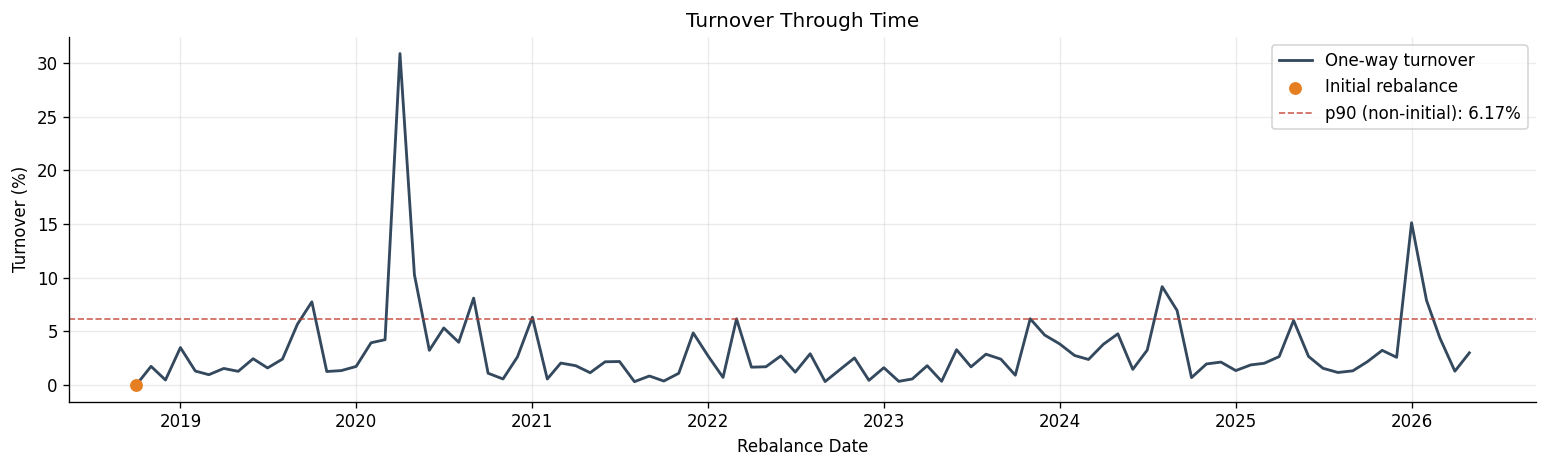

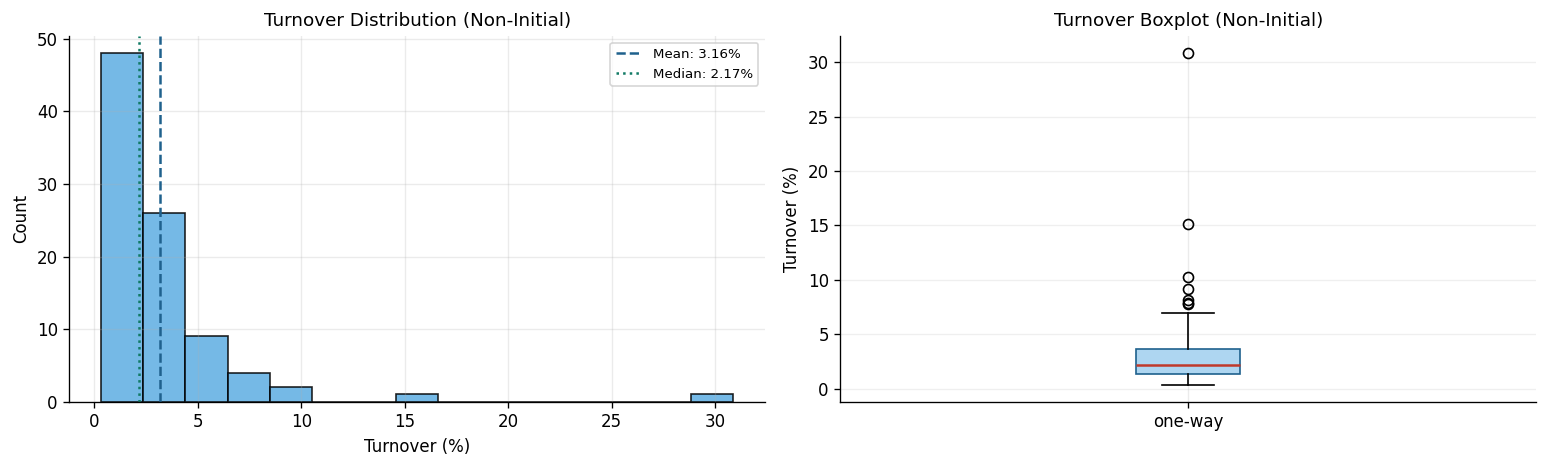

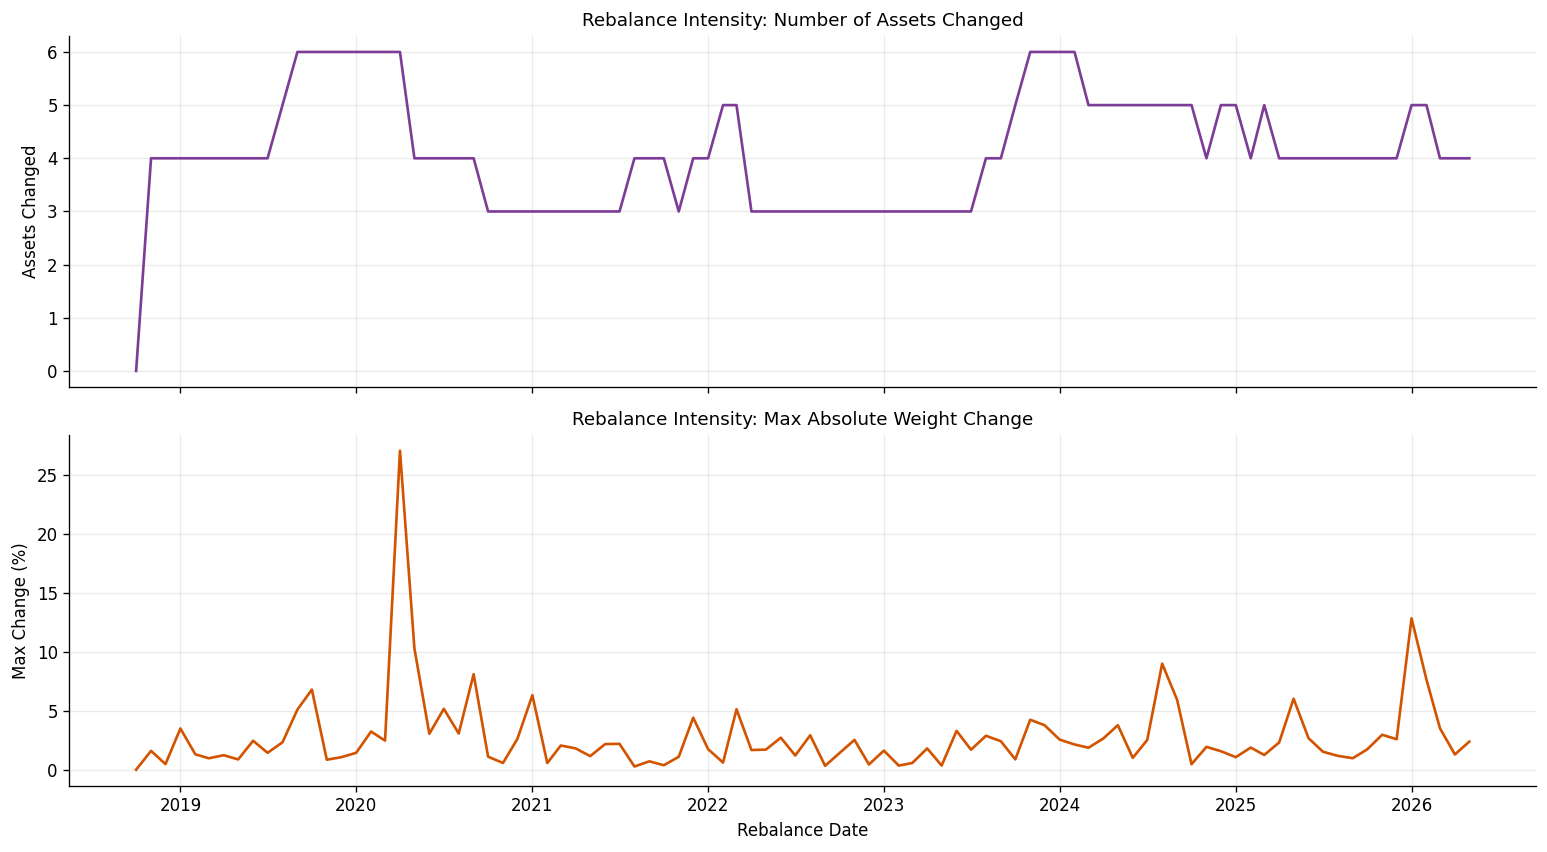

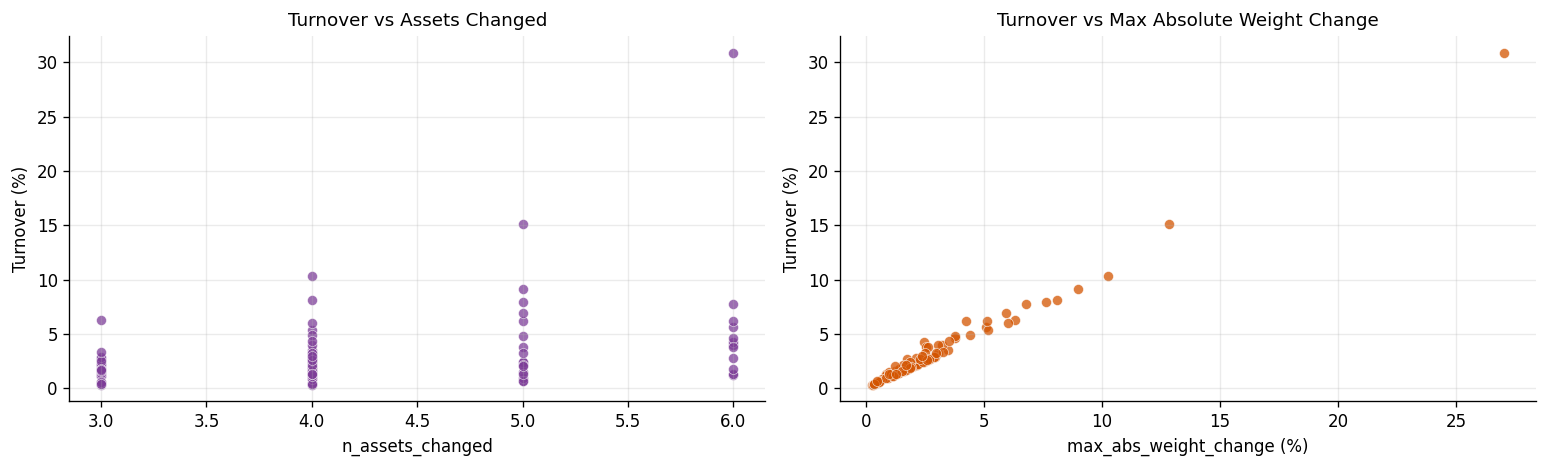

In [12]:
# ---- Section 6A-E: turnover and implementability diagnostics -----------------

t = turnover_history.copy().sort_index()

turnover_col = "turnover_one_way" if "turnover_one_way" in t.columns else None
if turnover_col is None:
    numeric_cols = t.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        turnover_col = numeric_cols[0]
        print(f"[Info] 'turnover_one_way' not found. Using '{turnover_col}' as turnover proxy.")
    else:
        raise ValueError("No numeric turnover column found in turnover_history.")

initial_col = "is_initial_rebalance" if "is_initial_rebalance" in t.columns else None
if initial_col is None:
    t["is_initial_rebalance"] = False
    initial_col = "is_initial_rebalance"
    print("[Info] 'is_initial_rebalance' not found. Treating all rows as non-initial.")

non_initial = ~t[initial_col].astype(bool)
t_eff = t.loc[non_initial].copy()

# A) Turnover summary table
summary_turnover = pd.DataFrame({
    "metric": [
        "total_rebalances",
        "non_initial_rebalances",
        "mean_turnover_non_initial",
        "median_turnover_non_initial",
        "max_turnover_non_initial",
        "mean_turnover_all",
    ],
    "value": [
        len(t),
        len(t_eff),
        t_eff[turnover_col].mean(),
        t_eff[turnover_col].median(),
        t_eff[turnover_col].max(),
        t[turnover_col].mean(),
    ]
})

turnover_percentiles = t_eff[turnover_col].quantile([0.75, 0.90, 0.95, 0.99]).rename("turnover")
turnover_tail_stats = pd.Series({
    "share_turnover_gt_5%": (t_eff[turnover_col] > 0.05).mean() * 100,
    "share_turnover_gt_10%": (t_eff[turnover_col] > 0.10).mean() * 100,
    "share_turnover_gt_20%": (t_eff[turnover_col] > 0.20).mean() * 100,
}).round(3)

summary_turnover_display = summary_turnover.copy()
summary_turnover_display["value_display"] = summary_turnover_display.apply(
    lambda r: f"{r['value']:.2%}" if "turnover" in r["metric"] else f"{int(r['value'])}",
    axis=1,
)

print("Turnover summary (non-initial emphasized):")
display(summary_turnover_display[["metric", "value_display"]].rename(columns={"value_display": "value"}))
print("Turnover percentiles (non-initial):")
display((turnover_percentiles * 100).round(3).to_frame("turnover_%"))
print("Turnover tail shares (non-initial):")
display(turnover_tail_stats.to_frame("value_%"))

# B) Time series of turnover
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t.index, t[turnover_col] * 100, color="#34495E", lw=1.7, label="One-way turnover")

if t[initial_col].any():
    t0 = t.loc[t[initial_col], turnover_col] * 100
    ax.scatter(t0.index, t0.values, color="#E67E22", s=45, zorder=3, label="Initial rebalance")

q90 = t_eff[turnover_col].quantile(0.90)
ax.axhline(q90 * 100, color="#C0392B", lw=1.0, ls="--", alpha=0.8,
           label=f"p90 (non-initial): {q90:.2%}")

ax.set_title("Turnover Through Time", fontsize=12)
ax.set_ylabel("Turnover (%)")
ax.set_xlabel("Rebalance Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# C) Turnover distribution (histogram + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(t_eff[turnover_col] * 100, bins=15, color="#5DADE2", edgecolor="black", alpha=0.85)
axes[0].axvline(t_eff[turnover_col].mean() * 100, color="#1F618D", lw=1.5, ls="--",
                label=f"Mean: {t_eff[turnover_col].mean():.2%}")
axes[0].axvline(t_eff[turnover_col].median() * 100, color="#117A65", lw=1.5, ls=":",
                label=f"Median: {t_eff[turnover_col].median():.2%}")
axes[0].set_title("Turnover Distribution (Non-Initial)", fontsize=11)
axes[0].set_xlabel("Turnover (%)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

axes[1].boxplot(t_eff[turnover_col] * 100, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#1F618D"),
                medianprops=dict(color="#C0392B", linewidth=1.5))
axes[1].set_title("Turnover Boxplot (Non-Initial)", fontsize=11)
axes[1].set_ylabel("Turnover (%)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["one-way"])
axes[1].grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

# D-E) Rebalance intensity and relation to allocation changes
has_n_changed = "n_assets_changed" in t.columns
has_max_abs = "max_abs_weight_change" in t.columns

if has_n_changed or has_max_abs:
    n_sub = (1 if has_n_changed else 0) + (1 if has_max_abs else 0)
    fig, axes = plt.subplots(n_sub, 1, figsize=(13, 3.6 * n_sub), sharex=True)
    if n_sub == 1:
        axes = [axes]

    k = 0
    if has_n_changed:
        ax = axes[k]
        ax.plot(t.index, t["n_assets_changed"], color="#7D3C98", lw=1.6)
        ax.set_title("Rebalance Intensity: Number of Assets Changed", fontsize=11)
        ax.set_ylabel("Assets Changed")
        ax.grid(alpha=0.25)
        k += 1

    if has_max_abs:
        ax = axes[k]
        ax.plot(t.index, t["max_abs_weight_change"] * 100, color="#D35400", lw=1.6)
        ax.set_title("Rebalance Intensity: Max Absolute Weight Change", fontsize=11)
        ax.set_ylabel("Max Change (%)")
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Rebalance Date")
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2 if (has_n_changed and has_max_abs) else 1, figsize=(13, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    j = 0
    if has_n_changed:
        ax = axes[j]
        ax.scatter(t_eff["n_assets_changed"], t_eff[turnover_col] * 100,
                   alpha=0.75, color="#7D3C98", edgecolor="white", linewidth=0.4)
        ax.set_title("Turnover vs Assets Changed", fontsize=11)
        ax.set_xlabel("n_assets_changed")
        ax.set_ylabel("Turnover (%)")
        ax.grid(alpha=0.25)
        j += 1

    if has_max_abs:
        ax = axes[j]
        ax.scatter(t_eff["max_abs_weight_change"] * 100, t_eff[turnover_col] * 100,
                   alpha=0.75, color="#D35400", edgecolor="white", linewidth=0.4)
        ax.set_title("Turnover vs Max Absolute Weight Change", fontsize=11)
        ax.set_xlabel("max_abs_weight_change (%)")
        ax.set_ylabel("Turnover (%)")
        ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()
else:
    print("[Info] Intensity columns not available ('n_assets_changed', 'max_abs_weight_change').")

# Persist artifacts for interpretation cell
turnover_section_artifacts = {
    "turnover_col": turnover_col,
    "summary": summary_turnover,
    "percentiles": turnover_percentiles,
    "tail_stats": turnover_tail_stats,
    "non_initial_series": t_eff[turnover_col],
    "q90_non_initial": q90,
    "has_n_assets_changed": has_n_changed,
    "has_max_abs_weight_change": has_max_abs,
}

### Lectura del turnover

**Pregunta.** ¿Es la carga operativa razonable para un esquema de rebalanceo periódico — *bruta* de cualquier supuesto de coste?

**Evidencia (rebalanceos non-initial).**
- Media ~3,16%; mediana ~2,17%. Percentiles: p75 ≈ 3,65%, p90 ≈ 6,18%, p95 ≈ 8,0%, p99 ≈ 16,7%.
- Intensidad de cola: ~15% de rebalanceos por encima del 5% de turnover, ~3% por encima del 10%, ~1% por encima del 20%.
- Los picos de turnover co-mueven más con `max_abs_weight_change` que con `n_assets_changed` — el motor ajusta *fuerte unas pocas posiciones*, en lugar de reordenar todo.

**Interpretación.** En términos brutos, la estrategia luce *operativamente plausible*: el rebalanceo mediano es un ajuste pequeño, la cola está concentrada y es identificable, y los corner cases son visibles más que ocultos.

**Límite inferencial.** *No* es una evaluación neta de costes. Una implementación realista incluye comisiones explícitas, bid-ask, slippage, impacto de mercado (Kyle, 1985; Almgren & Chriss, 2000) y ejecución parcial — nada de lo cual se modela aquí. El resultado de DeMiguel-Garlappi-Nogales-Uppal (2009) aplica directamente: el cost drag escala aproximadamente con el turnover, por lo que cualquier "alfa" del orden de tasa × turnover *no es robusto*. Una primera lectura net se realiza en el Notebook 02.


---
## 7 — Discusión

### 7.1 Lo que la evidencia respalda
- El baseline walk-forward OOS de MV exhibe un perfil claramente *defensivo* frente a benchmarks de mayor beta: menor volatilidad realizada, drawdowns menos profundos y una ventaja en Sharpe sobre 60/40 económicamente interpretable.
- La cesión riesgo–retorno está *cuantificada y es intuitiva*: la estrategia renuncia sistemáticamente a parte del upside en regímenes expansivos para comprimir la severidad de la cola izquierda. Coherente con el objetivo MV y con el papel regularizador de las restricciones (Jagannathan & Ma, 2003).
- La dinámica interna de la cartera — pesos, concentración, actividad de caps, turnover — es *trazable*. El baseline no es una caja negra; cada propiedad reportada es reconstruible desde los artefactos en `data/processed/`.

### 7.2 Lo que la evidencia aún no respalda
- *No* establece superioridad estadística de MV frente a los benchmarks; los gaps de Sharpe observados están dentro de la magnitud que DeMiguel, Garlappi & Uppal (2009) muestran como frecuentemente indistinguible de 1/N una vez que se modela el error de estimación.
- *No* establece que la (muy pequeña) contribución cripto sea *estable* ante cambios de parámetros — por construcción, el diagnóstico de activación es condicional al camino realizado.
- *No* entrega un veredicto económico neto de fricciones de trading; el análisis de turnover es solamente bruto.

### 7.3 Preguntas metodológicas abiertas
- ¿Cuán *sensible* es el resultado a la ventana de lookback (126 / 252 / 504), al cap cripto (0% / 10% / 20% / 25%) y al rebalanceo mensual vs. trimestral?
- ¿Qué fracción del edge bruto sobrevive bajo un wedge plausible de costes (10 / 25 / 50 bps)?
- ¿Cambia *materialmente* la asignación o la estabilidad de pesos al pasar a Ledoit-Wolf?
- ¿Algo de lo anterior es inferencialmente distinguible de cero bajo un *circular block bootstrap*?

### 7.4 Implicación para el siguiente capítulo
El paso siguiente correcto **no es** añadir complejidad de modelo (HRP, CVaR, condicionamiento por régimen, overlays ML). Es *estresar* el baseline a lo largo de las cuatro dimensiones anteriores — exactamente la agenda del Notebook 02. Añadir complejidad antes de checkear robustez confundiría "modelo más flexible" con "resultado más creíble", algo contra lo que la literatura advierte de forma consistente (Michaud, 1989; Harvey, Liu & Zhu, 2016).


---
## 8 — Limitaciones

Enumeración compacta y honesta de lo que limita el alcance inferencial del notebook.

| Dominio | Limitación | Implicación |
|---|---|---|
| Costes | Sin comisiones / spread / slippage / impacto explícitos. | La implementabilidad se lee solo en términos *brutos*. |
| Inferencia estadística | Sin intervalos bootstrap, sin tests de significatividad por subperiodo, sin tests formales de estabilidad. | Los diferenciales de performance son estimaciones puntuales sobre un único camino. |
| Estimador | Solo covarianza muestral — expuesta al error de estimación (Ledoit & Wolf, 2003). | La sensibilidad al estimador queda abierta; se aborda en el Cap. 2. |
| Vista de riesgo | Objetivo de varianza; sin CVaR / ES / drawdown-aware. | El riesgo de cola se *mide* pero no se *targetiza*. |
| Activación cripto | Estrictamente descriptiva, condicional al camino realizado. | Sin interpretación causal del cuándo/por qué entra crypto. |
| Concentración | HHI/ENB son diagnósticos en *espacio de pesos*. | No equivalen a concentración en *espacio de riesgo*. |
| Microestructura | Crypto opera 24/7, los activos tradicionales no. | Comparabilidad y realismo de ejecución no modelados. |
| Régimen | Una única realización OOS; sin condicionamiento formal por régimen. | Eventos como la correlación stock–bond de 2022 no son separables. |

**Lectura final de límites.** El notebook produce *evidencia descriptiva sólida sobre un baseline bien instrumentado* y un *encuadre honesto* de lo que esa evidencia no puede demostrar. Es una base, no un veredicto.


---
## 9 — Siguiente paso metodológico (entrega al Capítulo 2)

La decisión metodológica correcta *no* es enriquecer el modelo: es **estresar el baseline**. Hasta haber demostrado que los resultados actuales sobreviven a perturbaciones plausibles, añadir complejidad supondría ajustar más parámetros sobre la misma única trayectoria OOS.

**Agenda del Capítulo 2 (Notebook 02):**
1. **Sensibilidad de lookback** — 126 / 252 / 504 días, mismas restricciones.
2. **Sensibilidad del cap cripto** — 0% / 10% / 20% / 25%, incluyendo el control sin crypto.
3. **Sensibilidad de la frecuencia de rebalanceo** — mensual vs. trimestral, gross *y* net.
4. **Evaluación de costes de transacción** — 0 / 10 / 25 / 50 bps aplicados al turnover.
5. **Sensibilidad del estimador** — sample vs. Ledoit-Wolf shrinkage.
6. **Capa confirmatoria ligera** — circular block bootstrap (Politis & Romano, 1994) sobre un conjunto *preregistrado* de diferencias de Sharpe.

**Lógica de secuenciación.** Solo *después* de esta capa de robustez tiene sentido añadir objetivos CVaR/ES, HRP, condicionamiento por régimen u overlays ML — cada uno de los cuales es una *pregunta de investigación distinta*, no un refinamiento de la actual.

**Alcance de este notebook.** El Notebook 01 *no implementa* la agenda anterior. Su rol es (i) entregar un baseline limpio y reproducible, (ii) caracterizarlo descriptivamente OOS, y (iii) hacer explícita la frontera inferencial que el Capítulo 2 debe mover.


---
## References

- Almgren, R., & Chriss, N. (2000). *Optimal execution of portfolio transactions.* Journal of Risk, 3(2).
- Ang, A., & Bekaert, G. (2002). *International asset allocation with regime shifts.* Review of Financial Studies, 15(4).
- Best, M. J., & Grauer, R. R. (1991). *On the sensitivity of mean-variance-efficient portfolios to changes in asset means.* Review of Financial Studies, 4(2).
- Bouchaud, J.-P., Potters, M., & Aguilar, J.-P. (1997). *Missing information and asset allocation.* Working paper.
- Chopra, V. K., & Ziemba, W. T. (1993). *The effect of errors in means, variances, and covariances on optimal portfolio choice.* Journal of Portfolio Management, 19(2).
- DeMiguel, V., Garlappi, L., & Uppal, R. (2009). *Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy?* Review of Financial Studies, 22(5).
- DeMiguel, V., Garlappi, L., Nogales, F. J., & Uppal, R. (2009). *A generalized approach to portfolio optimization: improving performance by constraining portfolio norms.* Management Science, 55(5).
- Harvey, C. R., Liu, Y., & Zhu, H. (2016). *…and the cross-section of expected returns.* Review of Financial Studies, 29(1).
- Jagannathan, R., & Ma, T. (2003). *Risk reduction in large portfolios: why imposing the wrong constraints helps.* Journal of Finance, 58(4).
- Kyle, A. S. (1985). *Continuous auctions and insider trading.* Econometrica, 53(6).
- Ledoit, O., & Wolf, M. (2003). *Improved estimation of the covariance matrix of stock returns with an application to portfolio selection.* Journal of Empirical Finance, 10(5).
- Ledoit, O., & Wolf, M. (2004). *Honey, I shrunk the sample covariance matrix.* Journal of Portfolio Management, 30(4).
- Liu, Y., & Tsyvinski, A. (2021). *Risks and returns of cryptocurrency.* Review of Financial Studies, 34(6).
- Liu, Y., Tsyvinski, A., & Wu, X. (2022). *Common risk factors in cryptocurrency.* Journal of Finance, 77(2).
- Lo, A. W. (2002). *The statistics of Sharpe ratios.* Financial Analysts Journal, 58(4).
- Longin, F., & Solnik, B. (2001). *Extreme correlation of international equity markets.* Journal of Finance, 56(2).
- Markowitz, H. (1952). *Portfolio selection.* Journal of Finance, 7(1).
- Michaud, R. O. (1989). *The Markowitz optimization enigma: is "optimized" optimal?* Financial Analysts Journal, 45(1).
- Politis, D. N., & Romano, J. P. (1994). *The stationary bootstrap.* Journal of the American Statistical Association, 89(428).
